In [7]:
import pandas as pd
sku = pd.read_csv('sp.csv')
sku.head()

,Название,Артикул,Категория,Цена без карты,Цена с картой
0,Вентилятор BORGE Подкровельный Viotto черепаха...,17162001,Строительные материалы,1 514.15 ₽,1 438.44 ₽
1,Лента вентиляционная ПВХ 10х500 см,18824701,Строительные материалы,554.63 ₽,526.90 ₽
2,Проходка BORGE Кровельная D6-50мм прямая №1,17162301,Строительные материалы,329.33 ₽,312.86 ₽
3,Вентиляционная труба ОНДУВИЛЛА,19190801,Строительные материалы,4 099.00 ₽,3 894.05 ₽
4,Выход вентиляционный ТЕХНОНИКОЛЬ Изолированный...,19190601,Строительные материалы,3 799.00 ₽,3 609.05 ₽


In [8]:
sku.drop(columns=['Артикул', 'Цена без карты','Цена с картой'],inplace=True)
sku.rename(columns={"Название": "name", "Категория": "category"},inplace=True)
sku.head()

,name,category
0,Вентилятор BORGE Подкровельный Viotto черепаха...,Строительные материалы
1,Лента вентиляционная ПВХ 10х500 см,Строительные материалы
2,Проходка BORGE Кровельная D6-50мм прямая №1,Строительные материалы
3,Вентиляционная труба ОНДУВИЛЛА,Строительные материалы
4,Выход вентиляционный ТЕХНОНИКОЛЬ Изолированный...,Строительные материалы


Сгруппируем товары по их категории и посчитаем количество функциями groupby() и agg():

In [10]:
sku.groupby('category').agg(['count'])

,name
,count
category,
Автотовары,682
"Вентиляция, климатическое оборудование",410
"Двери, окна, замки",3235
"Инженерная электрика, лампы",4723
Инструменты и крепёж,7153
"Интерьер, текстиль, камины, оформление окон, картины",2889
Керамическая плитка,10399
"Краски, герметики, пропитки",1494


In [11]:
import nltk
from nltk.corpus import stopwords
from pymystem3 import Mystem
from string import punctuation
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/mugichu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [12]:
mystem = Mystem() 
russian_stopwords = stopwords.words("russian")
russian_stopwords.extend(['ассорт','разм','арт','что', 'это', 'так', 'вот', 'быть', 'как', 'в', '—', 'к', 'на'])

In [13]:
def preprocess_text(text):
    text = str(text)
    tokens = mystem.lemmatize(text.lower())
    tokens = [token for token in tokens if token not in russian_stopwords\
              and token != " " \
              and len(token)>=3 \
              and token.strip() not in punctuation \
              and token.isdigit()==False]
    text = " ".join(tokens)
    return text

In [14]:
preprocess_text("Мама мыла раму")

'мама мыть рама'

In [15]:
print('Было:', sku['name'][0])
print('Стало:', preprocess_text(sku['name'][0]))

Было: Вентилятор BORGE Подкровельный Viotto черепаха для МЧ
Стало: вентилятор borge подкровельный viotto черепаха


In [16]:
sku['processed']=sku['name'].apply(preprocess_text)
sku.head()

,name,category,processed
0,Вентилятор BORGE Подкровельный Viotto черепаха...,Строительные материалы,вентилятор borge подкровельный viotto черепаха
1,Лента вентиляционная ПВХ 10х500 см,Строительные материалы,лента вентиляционный пвх 10х500
2,Проходка BORGE Кровельная D6-50мм прямая №1,Строительные материалы,проходка borge кровельный 50мм прямая
3,Вентиляционная труба ОНДУВИЛЛА,Строительные материалы,вентиляционный труба ондувилла
4,Выход вентиляционный ТЕХНОНИКОЛЬ Изолированный...,Строительные материалы,выход вентиляционный технониколь изолированный...


<ipython-input-17-7e12a6eb4f0c>:28: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  plt.subplot(1, 2, 1)


<AxesSubplot:>

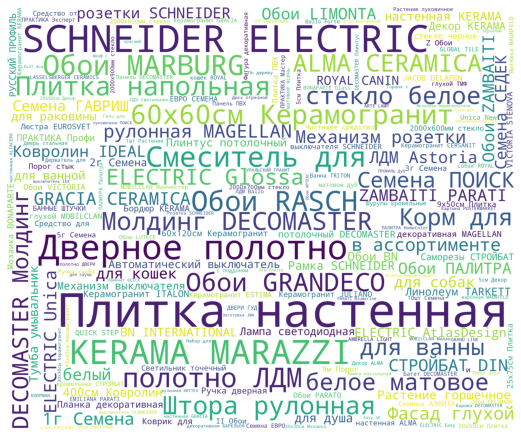

In [17]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
def str_corpus(corpus):
    str_corpus = ''
    for i in corpus:
        str_corpus += ' ' + i
    str_corpus = str_corpus.strip()
    return str_corpus
# Получение списка всех слов в корпусе
def get_corpus(data):
    corpus = []
    for phrase in data:
        for word in phrase.split():
            corpus.append(word)
    return corpus
# Получение облака слов
def get_wordCloud(corpus):
    wordCloud = WordCloud(background_color='white',width=3000,height=2500,max_words=200,random_state=42).generate(str_corpus(corpus))
    return wordCloud

corpus = get_corpus(sku['name'].values)
procWordCloud = get_wordCloud(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from imblearn.pipeline import Pipeline

In [20]:
x = sku.processed
y = sku.category
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.33)

In [21]:
text_clf = Pipeline([('vect', CountVectorizer(ngram_range=(1,2))),
                     ('tfidf', TfidfTransformer()), 
                    ('clf', MultinomialNB())])

In [22]:
text_clf = text_clf.fit(X_train, y_train)
y_pred = text_clf.predict(X_test)

In [23]:
print('Score:', text_clf.score(X_test, y_test))

Score: 0.9513697096364858


In [62]:
text = 'ламинат'

In [63]:
text_clf.predict([text])

array(['Напольные покрытия'], dtype='<U52')

In [57]:
my_products = pd.read_csv('leroy.csv')
my_products.head(5)

,Категория,Артикул,Наименование,Цена
0,Стройматериалы/Сухие смеси и грунтовки/Смеси д...,13401153.0,Наливной пол Unis Горизонт 20 кг,282
1,Стройматериалы/Сухие смеси и грунтовки/Смеси д...,14238167.0,Стяжка пола Лучшая Цена 25 кг,126
2,Стройматериалы/Сухие смеси и грунтовки/Смеси д...,13857230.0,Наливной пол Axton 20 кг,253
3,Стройматериалы/Сухие смеси и грунтовки/Смеси д...,15163419.0,Стяжка пола Axton 25 кг,137
4,Стройматериалы/Сухие смеси и грунтовки/Смеси д...,16096318.0,Наливной пол Ceresit CN 175 20 кг,374


In [32]:
my_products['processed']=my_products['Наименование'].apply(preprocess_text)
my_products.head()

,Категория,Артикул,Наименование,Цена,processed
0,Стройматериалы/Сухие смеси и грунтовки/Смеси д...,13401153.0,Наливной пол Unis Горизонт 20 кг,282,наливной пол unis горизонт
1,Стройматериалы/Сухие смеси и грунтовки/Смеси д...,14238167.0,Стяжка пола Лучшая Цена 25 кг,126,стяжка пол хороший цена
2,Стройматериалы/Сухие смеси и грунтовки/Смеси д...,13857230.0,Наливной пол Axton 20 кг,253,наливной пол axton
3,Стройматериалы/Сухие смеси и грунтовки/Смеси д...,15163419.0,Стяжка пола Axton 25 кг,137,стяжка пол axton
4,Стройматериалы/Сухие смеси и грунтовки/Смеси д...,16096318.0,Наливной пол Ceresit CN 175 20 кг,374,наливной пол ceresit


In [33]:
prediction = text_clf.predict(my_products['processed'])
my_products['prediction']=prediction
my_products[['Наименование', 'prediction']]

,Наименование,prediction
0,Наливной пол Unis Горизонт 20 кг,"Инженерная электрика, лампы"
1,Стяжка пола Лучшая Цена 25 кг,"Инженерная электрика, лампы"
2,Наливной пол Axton 20 кг,"Инженерная электрика, лампы"
3,Стяжка пола Axton 25 кг,"Инженерная электрика, лампы"
4,Наливной пол Ceresit CN 175 20 кг,Строительные материалы
...,...,...
181892,Сухой корм для собак мелких пород SAVARRA Adul...,"Товары для дома, подарки, бытовая химия"
181893,Сухой корм для щенков крупных пород SAVARRA ...,"Товары для дома, подарки, бытовая химия"
181894,Сухой корм для собак крупных пород SAVARRA Adu...,"Товары для дома, подарки, бытовая химия"
181895,Сухой корм для собак SAVARRA Adult Dog Turkey ...,"Товары для дома, подарки, бытовая химия"
